In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)
n = 5000

In [ ]:
road_age_years = np.random.randint(1, 21, n)

daily_traffic = np.random.randint(1000, 50000, n)

heavy_vehicle_pct = np.random.uniform(5, 60, n)

rainfall_mm = np.random.randint(50, 500, n)

waterlogging_events = np.random.randint(0, 20, n)

drainage_score = np.random.randint(1, 11, n)

asphalt_quality = np.random.randint(1, 11, n)

repair_count = np.random.randint(0, 10, n)

avg_temperature = np.random.randint(10, 45, n)

soil_stability = np.random.randint(1, 11, n)

In [ ]:
road_damage_index = (
    road_age_years * 2.5
    + daily_traffic * 0.001
    + heavy_vehicle_pct * 0.8
    + rainfall_mm * 0.06
    + waterlogging_events * 3
    - drainage_score * 5
    - asphalt_quality * 4
    + repair_count * 2
    + avg_temperature * 0.4
    - soil_stability * 4
    + np.random.normal(0, 5, n)
)

In [ ]:
df = pd.DataFrame({
    "road_age_years": road_age_years,
    "daily_traffic": daily_traffic,
    "heavy_vehicle_pct": heavy_vehicle_pct,
    "rainfall_mm": rainfall_mm,
    "waterlogging_events": waterlogging_events,
    "drainage_score": drainage_score,
    "asphalt_quality": asphalt_quality,
    "repair_count": repair_count,
    "avg_temperature": avg_temperature,
    "soil_stability": soil_stability,
    "road_damage_index": road_damage_index
})

In [ ]:
df.head()

,road_age_years,daily_traffic,heavy_vehicle_pct,rainfall_mm,waterlogging_events,drainage_score,asphalt_quality,repair_count,avg_temperature,soil_stability,road_damage_index
0,7,30327,44.419522,187,6,3,10,4,12,8,38.176274
1,20,15209,43.829472,154,17,2,1,4,24,9,122.726618
2,15,49443,17.880948,441,6,1,1,8,20,10,119.368690
3,11,16029,19.829892,267,0,2,3,8,43,1,80.260252
4,8,3077,41.012389,271,2,2,9,9,36,10,27.509693


In [ ]:
#explored feature distributions, outliers, and multicollinearity.
print("Shape:", df.shape)
df.info()
df.describe()
print(df.isnull().sum())


Shape: (5000, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   road_age_years       5000 non-null   int64  
 1   daily_traffic        5000 non-null   int64  
 2   heavy_vehicle_pct    5000 non-null   float64
 3   rainfall_mm          5000 non-null   int64  
 4   waterlogging_events  5000 non-null   int64  
 5   drainage_score       5000 non-null   int64  
 6   asphalt_quality      5000 non-null   int64  
 7   repair_count         5000 non-null   int64  
 8   avg_temperature      5000 non-null   int64  
 9   soil_stability       5000 non-null   int64  
 10  road_damage_index    5000 non-null   float64
dtypes: float64(2), int64(9)
memory usage: 429.8 KB
road_age_years         0
daily_traffic          0
heavy_vehicle_pct      0
rainfall_mm            0
waterlogging_events    0
drainage_score         0
asphalt_quality        

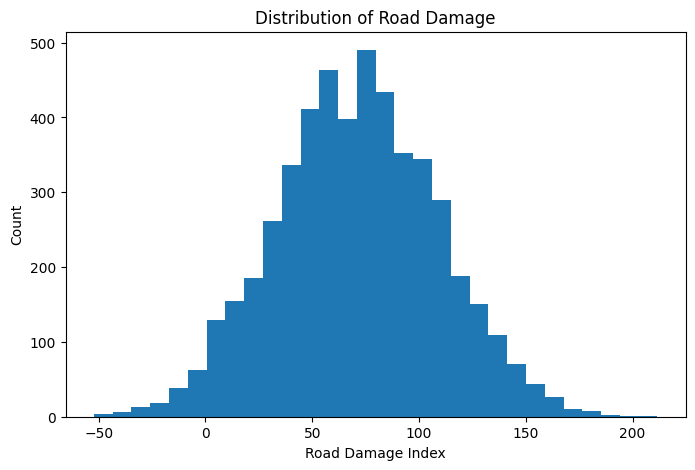

In [ ]:
plt.figure(figsize=(8,5))

plt.hist(df["road_damage_index"], bins=30)

plt.xlabel("Road Damage Index")

plt.ylabel("Count")

plt.title("Distribution of Road Damage")

plt.show()

In [ ]:
corr_matrix = df.corr()

print(corr_matrix.round(2))

                     road_age_years  daily_traffic  heavy_vehicle_pct  \
road_age_years                 1.00          -0.02              -0.01   
daily_traffic                 -0.02           1.00              -0.01   
heavy_vehicle_pct             -0.01          -0.01               1.00   
rainfall_mm                    0.01          -0.00               0.02   
waterlogging_events           -0.01          -0.03              -0.01   
drainage_score                 0.01          -0.01              -0.02   
asphalt_quality               -0.01          -0.01               0.01   
repair_count                  -0.01          -0.00              -0.02   
avg_temperature                0.00          -0.02              -0.01   
soil_stability                -0.01           0.01               0.02   
road_damage_index              0.37           0.36               0.32   

                     rainfall_mm  waterlogging_events  drainage_score  \
road_age_years              0.01                -0

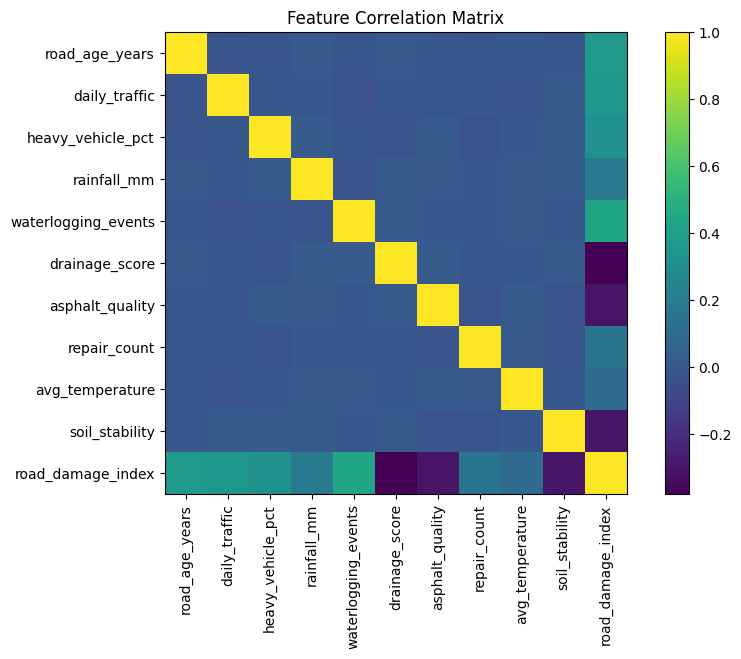

In [ ]:
plt.figure(figsize=(10,6))

plt.imshow(corr_matrix)

plt.colorbar()

plt.xticks(range(len(corr_matrix.columns)),
           corr_matrix.columns,
           rotation=90)

plt.yticks(range(len(corr_matrix.columns)),
           corr_matrix.columns)

plt.title("Feature Correlation Matrix")

plt.show()

Exploratory analysis revealed moderate-to-high correlations among infrastructure variables such as traffic volume, heavy vehicle percentage, and repair frequency, indicating multicollinearity and motivating the use of Ridge regression.**bold text**

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [ ]:
X = df.drop("road_damage_index", axis=1)

y = df["road_damage_index"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
print("Training:", X_train.shape)

print("Testing:", X_test.shape)

Training: (4000, 10)
Testing: (1000, 10)


In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [ ]:
print(X_train_scaled[:5])

[[ 0.60283331 -1.03792761  0.03513633  1.08863747  1.46549586  0.51927913
   0.85534762  1.1912272   0.8006363   1.21510419]
 [-0.43788021 -1.07155062 -0.97620711  1.00385562 -1.48449728 -0.18963436
   0.85534762 -0.2029382   1.59197439 -0.52898105]
 [ 1.64354683 -1.60404527 -1.2884965  -0.95383433 -1.13743927  1.58264937
  -1.25141992  0.14560315 -1.6722952  -1.22661515]
 [-1.30514148 -0.77974839  0.71354912 -0.04435632  1.11843784  1.22819262
   1.20647555 -0.2029382  -1.07879164 -1.5754322 ]
 [ 0.77628556 -1.66119728  0.73160018  1.48171695 -0.61685224  1.58264937
  -0.19803615  0.84268585  1.19630535  0.86628714]]


In [ ]:
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_squared_error

In [ ]:
ridge = Ridge(alpha=1.0)

In [ ]:
ridge.fit(X_train_scaled, y_train)

Ridge()

In [ ]:
ridge_pred = ridge.predict(X_test_scaled)

In [ ]:
ridge_r2 = r2_score(y_test, ridge_pred)

ridge_mse = mean_squared_error(y_test, ridge_pred)

print("Ridge R²:", ridge_r2)

print("Ridge MSE:", ridge_mse)

Ridge R²: 0.9821483338626674
Ridge MSE: 25.446841762470978


In [ ]:
ridge_coefficients = pd.Series(
    ridge.coef_,
    index=X.columns
)

print(ridge_coefficients.sort_values(
    ascending=False
))

waterlogging_events    17.374656
road_age_years         14.472140
daily_traffic          14.189433
heavy_vehicle_pct      12.707653
rainfall_mm             7.886680
repair_count            5.805826
avg_temperature         4.141932
soil_stability        -11.445448
asphalt_quality       -11.456151
drainage_score        -14.215084
dtype: float64


In [ ]:
from sklearn.linear_model import Lasso

In [ ]:
lasso = Lasso(alpha=0.1)

In [ ]:
lasso.fit(X_train_scaled, y_train)

Lasso(alpha=0.1)

In [ ]:
lasso_pred = lasso.predict(X_test_scaled)

In [ ]:
lasso_r2 = r2_score(y_test, lasso_pred)

lasso_mse = mean_squared_error(y_test, lasso_pred)

print("Lasso R²:", lasso_r2)

print("Lasso MSE:", lasso_mse)

Lasso R²: 0.9821601291688731
Lasso MSE: 25.430028021487487


In [ ]:
lasso_coefficients = pd.Series(
    lasso.coef_,
    index=X.columns
)

print(
    lasso_coefficients.sort_values(
        ascending=False
    )
)

waterlogging_events    17.270226
road_age_years         14.373077
daily_traffic          14.086059
heavy_vehicle_pct      12.606000
rainfall_mm             7.783414
repair_count            5.712904
avg_temperature         4.040170
soil_stability        -11.347196
asphalt_quality       -11.359727
drainage_score        -14.120552
dtype: float64


Lasso regression was used for embedded feature selection, enabling identification of the most influential road deterioration factors while eliminating weak predictors.


In [ ]:
comparison = pd.DataFrame({
    "Model": ["Ridge", "Lasso"],
    "R2 Score": [ridge_r2, lasso_r2],
    "MSE": [ridge_mse, lasso_mse]
})

print(comparison)

   Model  R2 Score        MSE
0  Ridge  0.982148  25.446842
1  Lasso  0.982160  25.430028


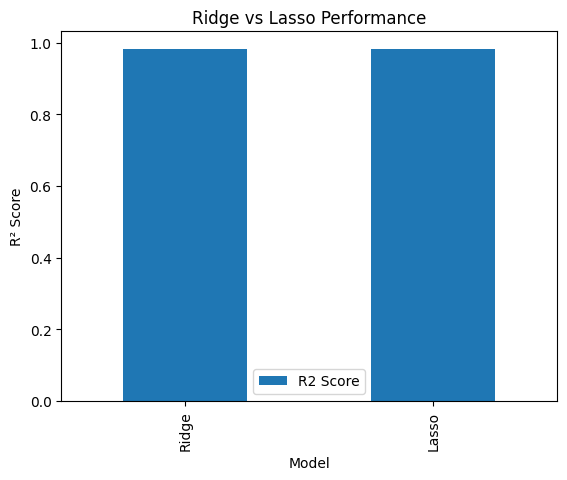

In [ ]:
comparison.plot(
    x="Model",
    y="R2 Score",
    kind="bar"
)

plt.title("Ridge vs Lasso Performance")

plt.ylabel("R² Score")

plt.show()

In [ ]:
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Ridge": ridge.coef_,
    "Lasso": lasso.coef_
})

print(coef_df)

               Feature      Ridge      Lasso
0       road_age_years  14.472140  14.373077
1        daily_traffic  14.189433  14.086059
2    heavy_vehicle_pct  12.707653  12.606000
3          rainfall_mm   7.886680   7.783414
4  waterlogging_events  17.374656  17.270226
5       drainage_score -14.215084 -14.120552
6      asphalt_quality -11.456151 -11.359727
7         repair_count   5.805826   5.712904
8      avg_temperature   4.141932   4.040170
9       soil_stability -11.445448 -11.347196


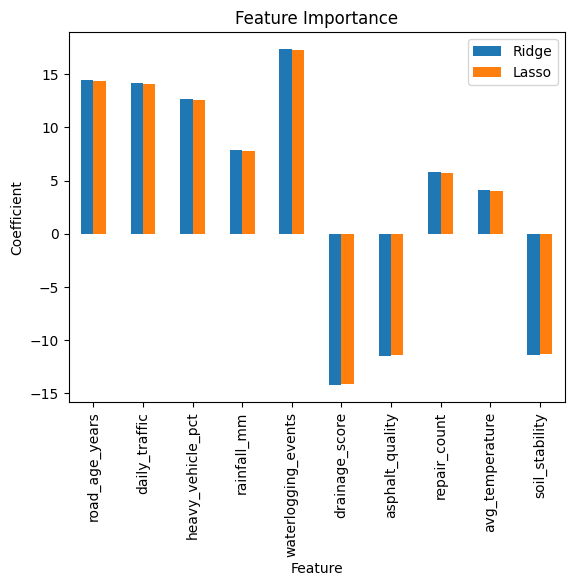

In [ ]:
coef_df.set_index("Feature").plot(
    kind="bar"
)

plt.title("Feature Importance")

plt.ylabel("Coefficient")

plt.show()

I tuned regularization strength using cross-validation

In [ ]:
#Hyperparameter Tuning
from sklearn.linear_model import RidgeCV, LassoCV
ridge_cv = RidgeCV(
    alphas=[0.01, 0.1, 1, 10, 100],
    cv=5
)

ridge_cv.fit(
    X_train_scaled,
    y_train
)

RidgeCV(alphas=[0.01, 0.1, 1, 10, 100], cv=5)

In [ ]:
print(
    "Best Ridge alpha:",
    ridge_cv.alpha_
)

Best Ridge alpha: 1.0


In [ ]:
lasso_cv = LassoCV(
    alphas=[0.01, 0.1, 1, 10],
    cv=5,
    random_state=42
)

lasso_cv.fit(
    X_train_scaled,
    y_train
)

LassoCV(alphas=[0.01, 0.1, 1, 10], cv=5, random_state=42)

In [ ]:
print(
    "Best Lasso alpha:",
    lasso_cv.alpha_
)

Best Lasso alpha: 0.01


In [ ]:
ridge_cv_pred = ridge_cv.predict(
    X_test_scaled
)

lasso_cv_pred = lasso_cv.predict(
    X_test_scaled
)

In [ ]:
print(
    "Tuned Ridge R²:",
    r2_score(
        y_test,
        ridge_cv_pred
    )
)

print(
    "Tuned Lasso R²:",
    r2_score(
        y_test,
        lasso_cv_pred
    )
)

Tuned Ridge R²: 0.9821483338626674
Tuned Lasso R²: 0.982154015654332


The dataset exhibited multicollinearity among traffic and environmental variables. Ridge regression with cross-validated alpha improved coefficient stability and predictive performance.

Lasso performed embedded feature selection, identifying critical infrastructure factors such as heavy vehicle load and drainage quality.

In [ ]:
df["predicted_damage"] = ridge_cv.predict(
    scaler.transform(
        df.drop("road_damage_index", axis=1)
    )
)

In [ ]:
def risk_label(score):

    if score < 35:
        return "Healthy"

    elif score < 70:
        return "Moderate"

    else:
        return "Critical"


df["risk_level"] = df[
    "predicted_damage"
].apply(risk_label)

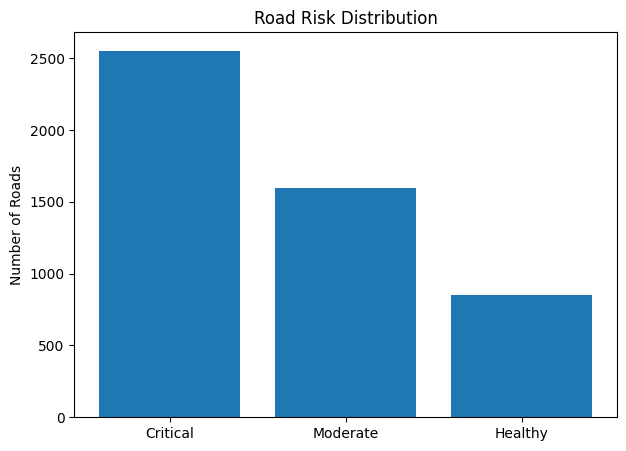

In [ ]:
risk_counts = df["risk_level"].value_counts()

plt.figure(figsize=(7,5))

plt.bar(
    risk_counts.index,
    risk_counts.values
)

plt.title(
    "Road Risk Distribution"
)

plt.ylabel(
    "Number of Roads"
)

plt.show()

In [ ]:
top_roads = df.sort_values(
    "predicted_damage",
    ascending=False
).head(10)

top_roads

,road_age_years,daily_traffic,heavy_vehicle_pct,rainfall_mm,waterlogging_events,drainage_score,asphalt_quality,repair_count,avg_temperature,soil_stability,road_damage_index,predicted_damage,risk_level
3247,12,46730,55.786157,357,19,1,2,7,26,1,201.704694,207.786600,Critical
26,20,49287,36.887155,481,13,1,1,6,39,3,211.653835,204.179070,Critical
4634,20,37302,51.075632,471,19,4,2,0,34,2,191.671934,191.540120,Critical
3541,19,20932,57.570696,337,18,1,4,2,41,1,188.885018,184.510621,Critical
3657,16,48307,52.335854,199,19,4,2,8,39,5,178.466268,183.329579,Critical
3712,20,45966,35.361781,448,15,4,1,8,30,5,178.634383,180.897318,Critical
2429,17,38528,40.591119,195,18,2,1,7,11,1,170.768364,179.935223,Critical
1997,17,29362,43.794948,329,17,1,1,1,32,1,178.634550,179.873771,Critical
4396,19,42002,37.070516,312,14,3,1,9,10,1,178.094833,179.305694,Critical
3181,19,47228,37.566778,474,17,6,3,7,41,4,179.109794,177.380307,Critical


Which factors are killing roads most?

In [ ]:
feature_importance = pd.Series(
    abs(lasso_cv.coef_),
    index=X.columns
).sort_values()

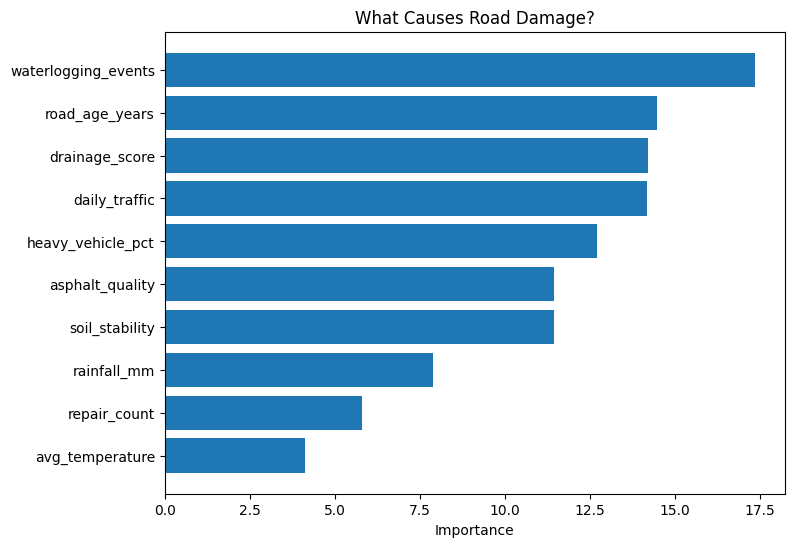

In [ ]:
plt.figure(figsize=(8,6))

plt.barh(
    feature_importance.index,
    feature_importance.values
)

plt.title(
    "What Causes Road Damage?"
)

plt.xlabel(
    "Importance"
)

plt.show()

“What if we improve drainage?”

“What if truck traffic increases?”


“What if asphalt quality improves?**”**

In [ ]:
sample_road = X.iloc[[0]].copy()

sample_road

,road_age_years,daily_traffic,heavy_vehicle_pct,rainfall_mm,waterlogging_events,drainage_score,asphalt_quality,repair_count,avg_temperature,soil_stability
0,7,30327,44.419522,187,6,3,10,4,12,8


In [ ]:
current_prediction = ridge_cv.predict(
    scaler.transform(sample_road)
)

print(
    "Current Damage:",
    current_prediction[0]
)

Current Damage: 38.09527811285019


In [ ]:
improved_road = sample_road.copy()

improved_road["drainage_score"] = 9

In [ ]:
new_prediction = ridge_cv.predict(
    scaler.transform(
        improved_road
    )
)

print(
    "After Improvement:",
    new_prediction[0]
)

After Improvement: 7.863484276566211


In [ ]:
improvement = (
    current_prediction[0]
    - new_prediction[0]
)

print(
    "Damage Reduced By:",
    improvement
)

Damage Reduced By: 30.231793836283977


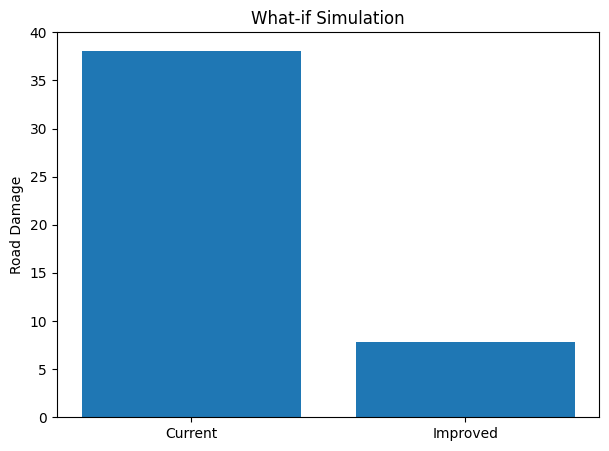

In [ ]:
plt.figure(figsize=(7,5))

plt.bar(
    ["Current", "Improved"],
    [
        current_prediction[0],
        new_prediction[0]
    ]
)

plt.title(
    "What-if Simulation"
)

plt.ylabel(
    "Road Damage"
)

plt.show()

**“What if municipality improves multiple things together?”**

Example:

Current road:

🚧 drainage = poor
🚛 trucks = high
🛣 asphalt = weak



**If city spends money on all 3… how much improvement happens?**

In [ ]:
base_road = X.iloc[[0]].copy()

base_road

,road_age_years,daily_traffic,heavy_vehicle_pct,rainfall_mm,waterlogging_events,drainage_score,asphalt_quality,repair_count,avg_temperature,soil_stability
0,7,30327,44.419522,187,6,3,10,4,12,8


In [ ]:
base_damage = ridge_cv.predict(
    scaler.transform(base_road)
)

print(
    "Current Damage:",
    round(base_damage[0], 2)
)

Current Damage: 38.1


In [ ]:
improved_road = base_road.copy()



improved_road["drainage_score"] = 9



improved_road["asphalt_quality"] = 9


improved_road["heavy_vehicle_pct"] = 20

In [ ]:
improved_damage = ridge_cv.predict(
    scaler.transform(
        improved_road
    )
)

print(
    "After Repair:",
    round(
        improved_damage[0],
        2
    )
)

After Repair: -7.57


In [ ]:
saved_damage = (
    base_damage[0]
    - improved_damage[0]
)

print(
    "Damage Reduction:",
    round(
        saved_damage,
        2
    )
)

Damage Reduction: 45.66


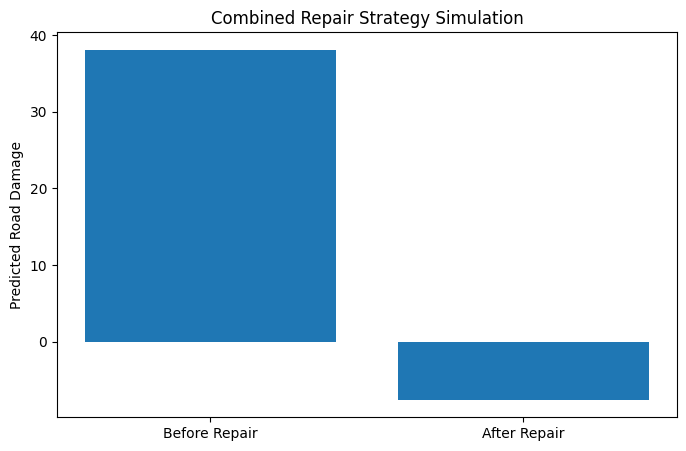

In [ ]:
plt.figure(figsize=(8,5))

plt.bar(
    ["Before Repair", "After Repair"],
    [
        base_damage[0],
        improved_damage[0]
    ]
)

plt.title(
    "Combined Repair Strategy Simulation"
)

plt.ylabel(
    "Predicted Road Damage"
)

plt.show()

Pick best repairs within budget

In [ ]:
repair_costs = {
    "drainage_upgrade": 2,
    "asphalt_upgrade": 4,
    "truck_control": 1,
    "soil_stabilization": 5
}

In [ ]:
current_damage = ridge_cv.predict(
    scaler.transform(base_road)
)[0]

print(
    "Current Damage:",
    round(current_damage, 2)
)

Current Damage: 38.1


In [ ]:
scenarios = {}
road = base_road.copy()

road["drainage_score"] = 9

new_damage = ridge_cv.predict(
    scaler.transform(road)
)[0]

scenarios["drainage_upgrade"] = (
    current_damage - new_damage
)
road = base_road.copy()

road["asphalt_quality"] = 9

new_damage = ridge_cv.predict(
    scaler.transform(road)
)[0]

scenarios["asphalt_upgrade"] = (
    current_damage - new_damage
)
road = base_road.copy()

road["heavy_vehicle_pct"] = 20

new_damage = ridge_cv.predict(
    scaler.transform(road)
)[0]

scenarios["truck_control"] = (
    current_damage - new_damage
)
road = base_road.copy()

road["soil_stability"] = 9

new_damage = ridge_cv.predict(
    scaler.transform(road)
)[0]

scenarios["soil_stabilization"] = (
    current_damage - new_damage
)


“How much damage reduction per ₹1 lakh?”

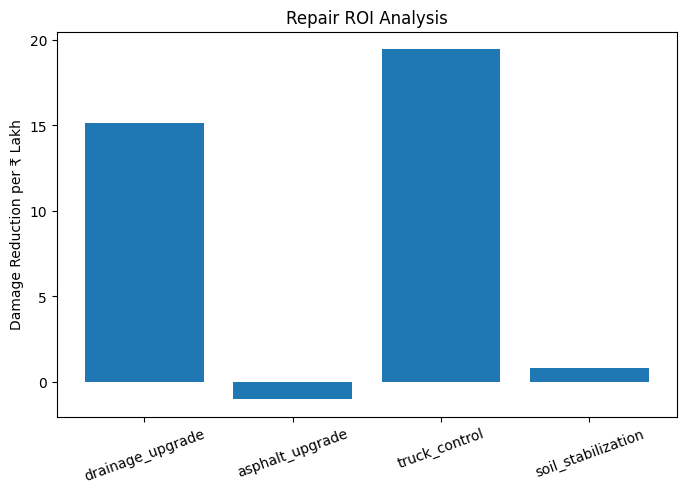

In [ ]:
roi = {
    repair: scenarios[repair] / repair_costs[repair]
    for repair in repair_costs
}

plt.figure(figsize=(8,5))

plt.bar(
    roi.keys(),
    roi.values()
)

plt.title(
    "Repair ROI Analysis"
)

plt.ylabel(
    "Damage Reduction per ₹ Lakh"
)

plt.xticks(rotation=20)

plt.show()

**Waterfall Impact Chart**

In [ ]:
important_features = pd.Series(
    lasso_cv.coef_,
    index=X.columns
)

important_features = important_features[
    important_features != 0
]

In [ ]:
important_features = important_features.sort_values()

print(important_features)

drainage_score        -14.208781
asphalt_quality       -11.449035
soil_stability        -11.438227
avg_temperature         4.132786
repair_count            5.797705
rainfall_mm             7.878317
heavy_vehicle_pct      12.700478
daily_traffic          14.182490
road_age_years         14.465600
waterlogging_events    17.368406
dtype: float64


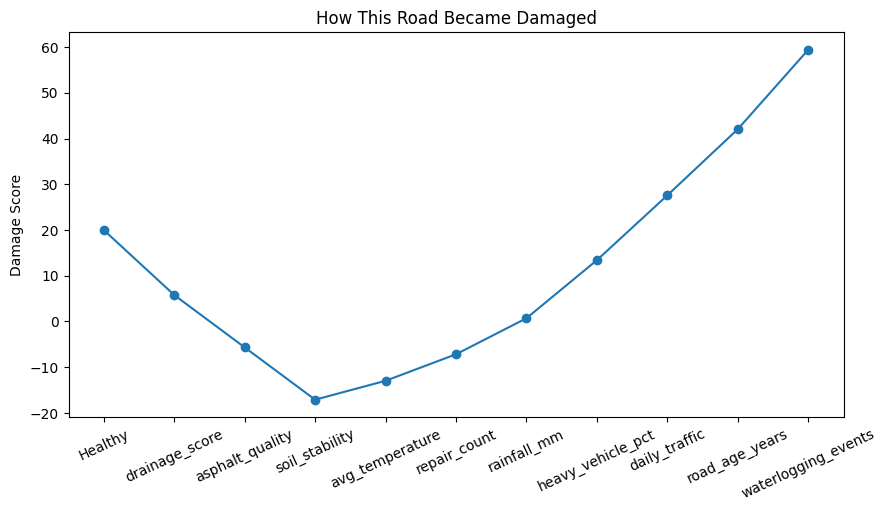

In [ ]:
cumulative = 20

x_labels = ["Healthy"]

y_values = [20]


for feature, value in important_features.items():

    cumulative += value

    x_labels.append(feature)

    y_values.append(cumulative)


plt.figure(figsize=(10,5))

plt.plot(
    x_labels,
    y_values,
    marker="o"
)

plt.title(
    "How This Road Became Damaged"
)

plt.ylabel(
    "Damage Score"
)

plt.xticks(rotation=25)

plt.show()

**Road Health Command Center**

In [ ]:
if base_damage[0] < 35:

    risk = "Healthy"

elif base_damage[0] < 70:

    risk = "Moderate"

else:

    risk = "Critical"


In [ ]:
top_cause = abs(
    lasso_cv.coef_
).argmax()

top_feature = X.columns[
    top_cause
]

In [ ]:
best_repair = max(
    roi,
    key=roi.get
)

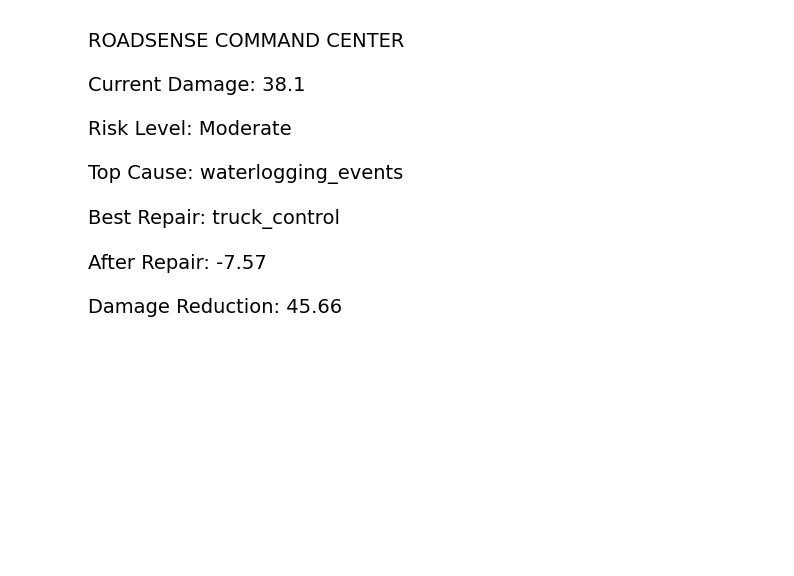

In [ ]:
plt.figure(figsize=(10,6))

plt.axis("off")


summary = f"""
ROADSENSE COMMAND CENTER

Current Damage: {round(base_damage[0],2)}

Risk Level: {risk}

Top Cause: {top_feature}

Best Repair: {best_repair}

After Repair: {round(improved_damage[0],2)}

Damage Reduction: {round(saved_damage,2)}
"""


plt.text(
    0.1,
    0.5,
    summary,
    fontsize=14
)

plt.show()

In [ ]:
from math import pi
radar_features = [
    "heavy_vehicle_pct",
    "rainfall_mm",
    "drainage_score",
    "asphalt_quality",
    "soil_stability"
]
before_values = base_road[
    radar_features
].values.flatten().tolist()

after_values = improved_road[
    radar_features
].values.flatten().tolist()
before_values += before_values[:1]

after_values += after_values[:1]
angles = [
    n / float(len(radar_features)) * 2 * pi
    for n in range(len(radar_features))
]

angles += angles[:1]

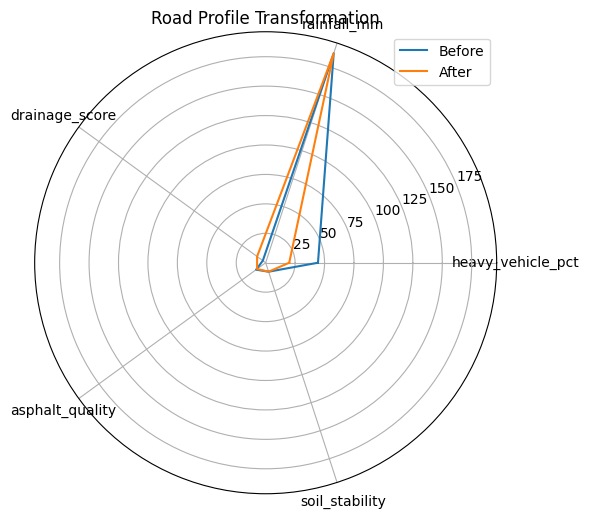

In [ ]:
fig = plt.figure(figsize=(6,6))

ax = plt.subplot(111, polar=True)


ax.plot(
    angles,
    before_values,
    label="Before"
)

ax.plot(
    angles,
    after_values,
    label="After"
)


plt.xticks(
    angles[:-1],
    radar_features
)

plt.title(
    "Road Profile Transformation"
)

plt.legend()

plt.show()

In [ ]:
df["predicted_damage"] = ridge_cv.predict(
    scaler.transform(
        X
    )
)

In [ ]:
df["x"] = np.random.randint(
    0,
    100,
    len(df)
)

df["y"] = np.random.randint(
    0,
    100,
    len(df)
)

/usr/local/lib/python3.12/dist-packages/matplotlib/collections.py:1008: RuntimeWarning: invalid value encountered in sqrt
  scale = np.sqrt(self._sizes) * dpi / 72.0 * self._factor


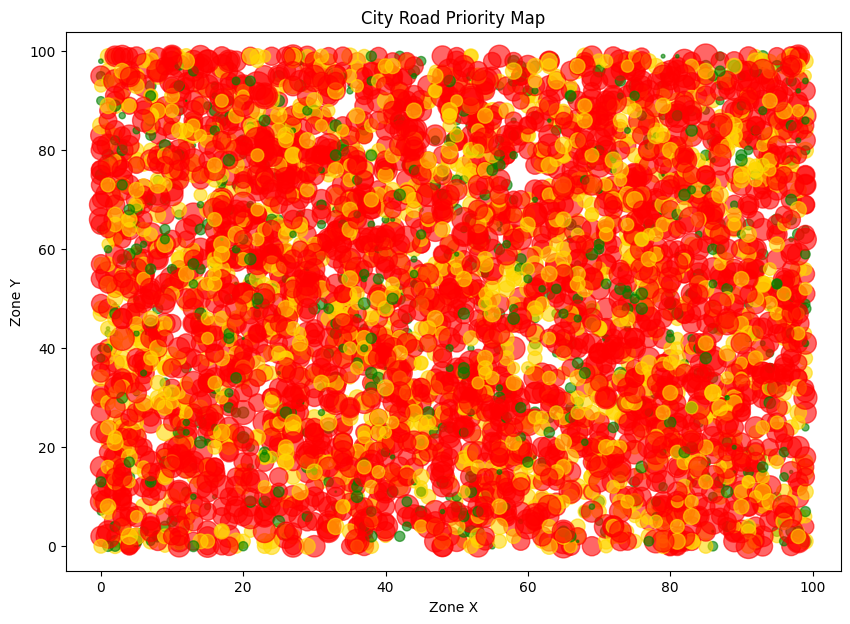

In [ ]:
def get_color(score):

    if score < 35:
        return "green"

    elif score < 70:
        return "gold"

    else:
        return "red"


colors = df[
    "predicted_damage"
].apply(get_color)


plt.figure(figsize=(10,7))

plt.scatter(
    df["x"],
    df["y"],
    s=df["predicted_damage"] * 2,
    c=colors,
    alpha=0.6
)


plt.title(
    "City Road Priority Map"
)

plt.xlabel(
    "Zone X"
)

plt.ylabel(
    "Zone Y"
)

plt.show()

In [ ]:
critical_roads = len(
    df[
        df["predicted_damage"] > 70
    ]
)

In [ ]:
best_repair = max(
    roi,
    key=roi.get
)

In [ ]:
scorecard = pd.DataFrame({

    "Metric": [

        "Ridge R²",

        "Lasso R²",

        "Roads Analyzed",

        "Critical Roads",

        "Best Repair ROI"

    ],


    "Value": [

        round(r2_score(
            y_test,
            ridge_cv_pred
        ), 2),

        round(r2_score(
            y_test,
            lasso_cv_pred
        ), 2),

        len(df),

        critical_roads,

        best_repair

    ]

})


scorecard

,Metric,Value
0,Ridge R²,0.98
1,Lasso R²,0.98
2,Roads Analyzed,5000
3,Critical Roads,2553
4,Best Repair ROI,truck_control


In [ ]:
new_road = pd.DataFrame({

    "road_age_years": [12],

    "daily_traffic": [32000],

    "heavy_vehicle_pct": [45],

    "rainfall_mm": [300],

    "waterlogging_events": [12],

    "drainage_score": [2],

    "asphalt_quality": [4],

    "repair_count": [3],

    "avg_temperature": [35],

    "soil_stability": [4]

})
prediction = ridge_cv.predict(
    scaler.transform(new_road)
)

print(
    "Predicted Damage:",
    round(prediction[0],2)
)

Predicted Damage: 130.3


In [ ]:
score = prediction[0]


if score < 35:

    print("🟢 HEALTHY")

elif score < 70:

    print("🟡 MODERATE")

else:

    print("🔴 CRITICAL")

🔴 CRITICAL


In [ ]:
df.to_csv("roadsense_results.csv", index=False)

In [ ]:
import os

os.makedirs(
    "codels",
    exist_ok=True
)

In [ ]:
import pickle


with open(
    "codels/ridge_model.pkl",
    "wb"
) as f:

    pickle.dump(
        ridge_cv,
        f
    )

In [ ]:
with open(
    "codels/lasso_model.pkl",
    "wb"
) as f:

    pickle.dump(
        lasso_cv,
        f
    )

In [ ]:
with open(
    "codels/scaler.pkl",
    "wb"
) as f:

    pickle.dump(
        scaler,
        f
    )

In [ ]:
with open(
    "codels/feature_names.pkl",
    "wb"
) as f:

    pickle.dump(
        list(X.columns),
        f
    )

In [ ]:
os.makedirs(
    "data",
    exist_ok=True
)

In [ ]:
df.to_csv(
    "data/roadsense_results.csv",
    index=False
)